# DA 351 Lab 5: Advanced Image Classification  

- Names: Bach Nguyen, Ichhit Joshi, Suveer Singh, and Zach Riethof 
- Date:  4/16/2024

- Question Topic
    - In this analysis, our group will use the TensorFlow package in Python to classify folders containing images of different North American birds. We are basing our approach on the article 'Building a Bird Recognition App and Large Scale Dataset With Citizen Scientists: The Fine Print in Fine-Grained Dataset Collection'.

## Introduction

- This week's lab is based on an article titled 'Building a Bird Recognition App and Large Scale Dataset With Citizen Scientists: The Fine Print in Fine-Grained Dataset Collection,' authored by the SE(3) Computer Vision Group at Cornell University. The dataset they created, NABirds, contains 48,562 images of North American birds categorized into 555 categories. However, the main issue with this dataset is its size—it is quite large, with a size of 9.8 GB compressed on my disk and 9.99 GB after extraction. Our group for this lab has decided to work with the Caltech-UCSD Birds-200-2011 Dataset (CUB 200), which was the go-to dataset for bird recognition and classification before NABirds. CUB 200 is still fairly large at 1.2 GB compressed, but it is significantly smaller than 9.8 GB. 

- In this lab, we aim to classify images of different North American birds using the Caltech-UCSD Birds-200-2011 Dataset (CUB 200). Some questions we are trying to answer include: Can we accurately classify different species of North American birds based on their images? Are there specific features or characteristics of bird images that are particularly informative for classification?

- The stakeholders for our data analysis lab include us, the students, who serve as team members responsible for carrying out tasks to achieve the project's overall goals. Another significant stakeholder is our professor, Mr. Lavin, who oversees our project and provides assistance on tasks if needed. Additionally, Cornell University is a stakeholder, as the dataset for this project was researched and compiled by this institution. They might be interested in the outcomes of our work. In our project, we are committed to upholding ethical standards throughout the process. We recognize the importance of data privacy and are ensuring that the images used for classification are obtained and used in compliance with privacy regulations. Since we have been provided with the dataset by our professor, we are confident that we have consent from the maker of the dataset to use it. To mitigate bias, we are carefully selecting diverse and representative images in our dataset for training and testing our models. We are also transparently documenting the architecture and parameters of our CNN models to ensure transparency. Additionally, we are monitoring our models' performance across different categories to detect and mitigate any bias that might be present.    

__Pairings:__

- (a) California Gull vs Ring Billed Gull: We believe the binary classifier will face challenges in distinguishing between the two bird species, as they belong to the same species. We chose to compare two Gull species that are very similar to each other, presenting a challenge for the binary classifier.   
- (b) Chipping Sparrow vs Fox Sparrow: We believe the binary classifier will face challenges in distinguishing between the two bird species, as they belong to the same species. We chose to compare these two sparrow species because both birds have very similar colors, which would present a significant challenge to the binary classifier.   
- (c) Pileated Woodpecker vs Red headed Woodpecker: We anticipate that the binary classifier may encounter challenges in distinguishing between the two bird species, given that they belong to the same species. We chose to compare these two woodpecker species because both birds have very similar coloring; both have red on their head, which might present a challenge for the binary classifier.
- (d) Blue Grosbeak vs Long tailed Jaeger: We expect the binary classifier to effectively differentiate between these two bird species. We selected these two bird species for their distinct differences in color, size, and shape, anticipating that the binary classifier will easily distinguish between them. 
- (e) White Pelican vs Yellow Warbler: We expect the binary classifier to effectively differentiate between these two bird species. We selected these two bird species because they are very different from each other in many aspects, as we think that the binary classifier will have a easy time distinguishing between them.  
- (f) Painted Bunting vs Summer Tanager: We anticipate that the binary classifier may face challenges in distinguishing between the two bird species. We selected these two species because they share the same shape and size but can be easily differentiated by their colors, presenting an interesting challenge for the binary classifier. 
- (g) Hooded Warbler vs Red bellied Woodpecker: We expect the binary classifier to effectively differentiate between these two bird species. We selected these two species specifically for their clear differences in color, which we believe will make it easy for the binary classifier to distinguish between them.
- (h) Red winged Blackbird vs Lazuli Bunting: We anticipate that the binary classifier will effectively differentiate between these two bird species. We selected these species based on their distinct differences in color and shape, which should facilitate accurate classification by the binary classifier.  
- (i) Hooded Merganser vs Nighthawk: We anticipate that the binary classifier may face challenges in distinguishing between the two bird species. We selected these two species because they share the same color combination, with both species exhibiting a mix of brown and black. This similarity may pose a challenge for the binary classifier when distinguishing between them.   
- (j) Brown Pelican vs White Pelican: We believe the binary classifier will face challenges in distinguishing between the two bird species, as they belong to the same species. We chose to compare two pelican species that look nearly identical, with the only clear difference being color. This similarity would present a challenge for the binary classifier.

# Code & Results

In [1]:
%matplotlib inline
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from keras.preprocessing import image
import cv2
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import seaborn as sns
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

### Training and Evaluating 10 Binary Classification Models

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 10ms/step

Model Accuracy of pairing a :
0.6666666666666666

Confusion Matrix of pairing a :
[[14  6]
 [ 6 10]]


True Negatives (TN) of pairing a : 14
False Positives (FP) of pairing a : 6
False Negatives (FN) of pairing a : 6
True Positives (TP) of pairing a : 10

Precision of pairing a :
[0.7   0.625]

Recall of pairing a :
[0.7   0.625]


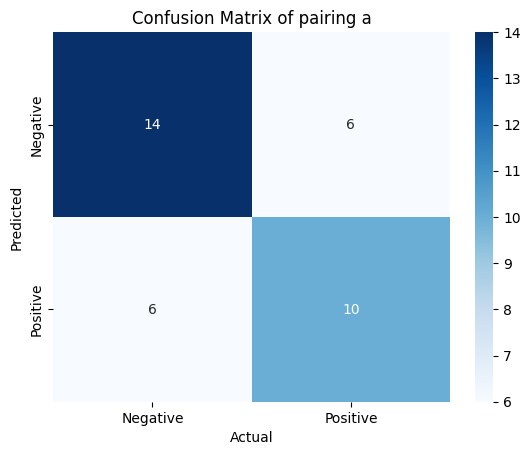

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 10ms/step

Model Accuracy of pairing b :
0.5555555555555556

Confusion Matrix of pairing b :
[[12  8]
 [ 8  8]]


True Negatives (TN) of pairing b : 12
False Positives (FP) of pairing b : 8
False Negatives (FN) of pairing b : 8
True Positives (TP) of pairing b : 8

Precision of pairing b :
[0.6 0.5]

Recall of pairing b :
[0.6 0.5]


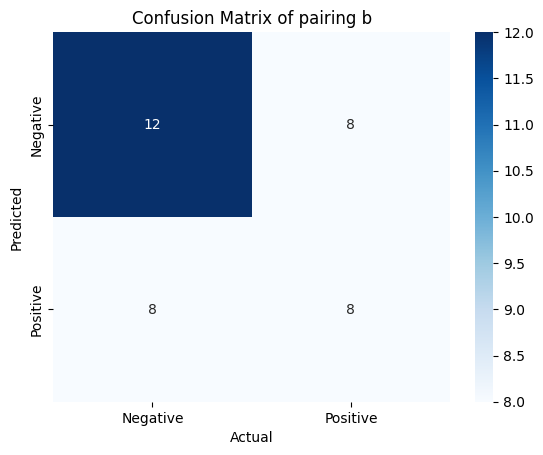

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 10ms/step

Model Accuracy of pairing c :
0.6666666666666666

Confusion Matrix of pairing c :
[[14  6]
 [ 6 10]]


True Negatives (TN) of pairing c : 14
False Positives (FP) of pairing c : 6
False Negatives (FN) of pairing c : 6
True Positives (TP) of pairing c : 10

Precision of pairing c :
[0.7   0.625]

Recall of pairing c :
[0.7   0.625]


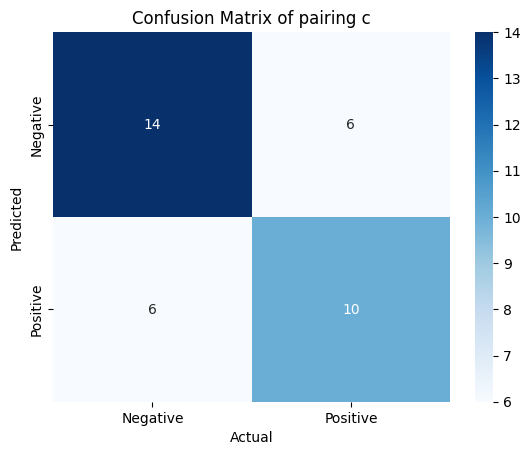

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 10ms/step

Model Accuracy of pairing d :
0.7777777777777778

Confusion Matrix of pairing d :
[[16  4]
 [ 4 12]]


True Negatives (TN) of pairing d : 16
False Positives (FP) of pairing d : 4
False Negatives (FN) of pairing d : 4
True Positives (TP) of pairing d : 12

Precision of pairing d :
[0.8  0.75]

Recall of pairing d :
[0.8  0.75]


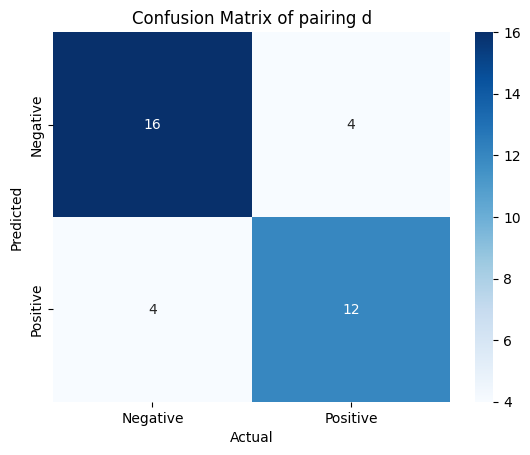

Found 110 files belonging to 2 classes.
Using 77 files for training.
Found 110 files belonging to 2 classes.
Using 33 files for validation.
Found 110 files belonging to 2 classes.
33/33 [==============================] - 0s 9ms/step

Model Accuracy of pairing e :
0.8787878787878788

Confusion Matrix of pairing e :
[[17  2]
 [ 2 12]]


True Negatives (TN) of pairing e : 17
False Positives (FP) of pairing e : 2
False Negatives (FN) of pairing e : 2
True Positives (TP) of pairing e : 12

Precision of pairing e :
[0.89473684 0.85714286]

Recall of pairing e :
[0.89473684 0.85714286]


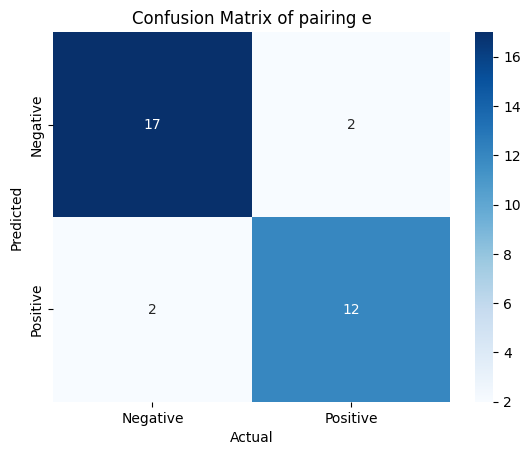

Found 118 files belonging to 2 classes.
Using 83 files for training.
Found 118 files belonging to 2 classes.
Using 35 files for validation.
Found 118 files belonging to 2 classes.
35/35 [==============================] - 0s 11ms/step

Model Accuracy of pairing f :
0.8857142857142857

Confusion Matrix of pairing f :
[[18  2]
 [ 2 13]]


True Negatives (TN) of pairing f : 18
False Positives (FP) of pairing f : 2
False Negatives (FN) of pairing f : 2
True Positives (TP) of pairing f : 13

Precision of pairing f :
[0.9        0.86666667]

Recall of pairing f :
[0.9        0.86666667]


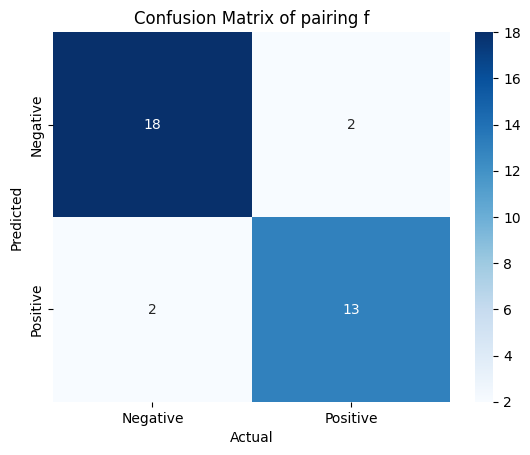

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 10ms/step

Model Accuracy of pairing g :
0.7222222222222222

Confusion Matrix of pairing g :
[[15  5]
 [ 5 11]]


True Negatives (TN) of pairing g : 15
False Positives (FP) of pairing g : 5
False Negatives (FN) of pairing g : 5
True Positives (TP) of pairing g : 11

Precision of pairing g :
[0.75   0.6875]

Recall of pairing g :
[0.75   0.6875]


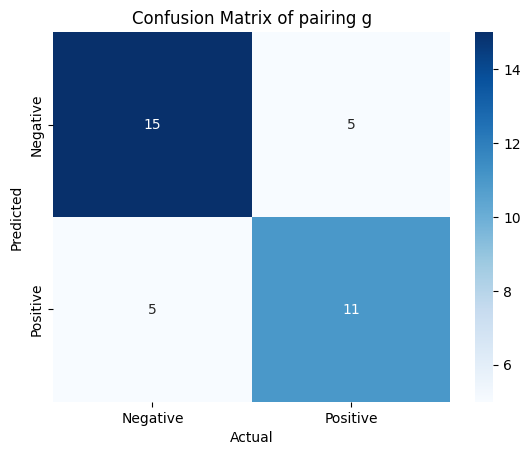

Found 118 files belonging to 2 classes.
Using 83 files for training.
Found 118 files belonging to 2 classes.
Using 35 files for validation.
Found 118 files belonging to 2 classes.
35/35 [==============================] - 0s 9ms/step

Model Accuracy of pairing h :
0.8857142857142857

Confusion Matrix of pairing h :
[[18  2]
 [ 2 13]]


True Negatives (TN) of pairing h : 18
False Positives (FP) of pairing h : 2
False Negatives (FN) of pairing h : 2
True Positives (TP) of pairing h : 13

Precision of pairing h :
[0.9        0.86666667]

Recall of pairing h :
[0.9        0.86666667]


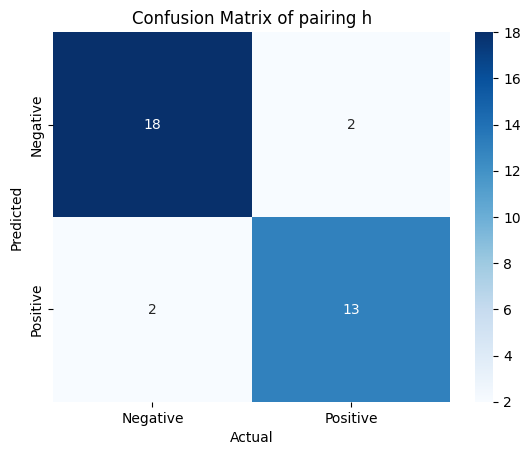

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 10ms/step

Model Accuracy of pairing i :
0.7777777777777778

Confusion Matrix of pairing i :
[[16  4]
 [ 4 12]]


True Negatives (TN) of pairing i : 16
False Positives (FP) of pairing i : 4
False Negatives (FN) of pairing i : 4
True Positives (TP) of pairing i : 12

Precision of pairing i :
[0.8  0.75]

Recall of pairing i :
[0.8  0.75]


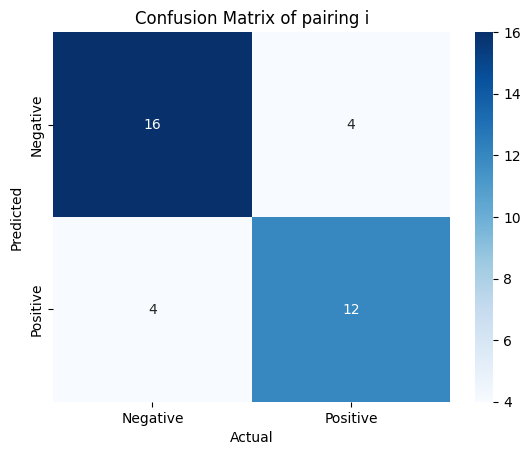

Found 110 files belonging to 2 classes.
Using 77 files for training.
Found 110 files belonging to 2 classes.
Using 33 files for validation.
Found 110 files belonging to 2 classes.
33/33 [==============================] - 0s 10ms/step

Model Accuracy of pairing j :
0.696969696969697

Confusion Matrix of pairing j :
[[17  5]
 [ 5  6]]


True Negatives (TN) of pairing j : 17
False Positives (FP) of pairing j : 5
False Negatives (FN) of pairing j : 5
True Positives (TP) of pairing j : 6

Precision of pairing j :
[0.77272727 0.54545455]

Recall of pairing j :
[0.77272727 0.54545455]


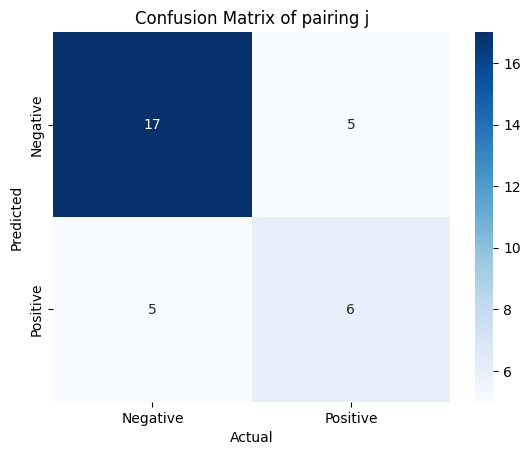

In [2]:
# Dictionary to store all 10 models
trained_models = {}

for pairing in sorted(os.listdir('bird_images')):
    
    model = tf.keras.models.Sequential([
    # Note the input shape is the desired size of the image 200x200 with 3 bytes color
    # The first convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),
    # The second convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    # The third convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    # Only 1 output neuron. It will contain a value from 0-1 
    tf.keras.layers.Dense(1, activation='sigmoid')])

    RMSprop = tf.keras.dtensor.experimental.optimizers.RMSprop
    model.compile(loss='binary_crossentropy',optimizer=RMSprop(),metrics='accuracy')

    pairing_path = os.path.join('bird_images', pairing)

    # Check if the path is a directory
    if os.path.isdir(pairing_path):
        training_set = tf.keras.utils.image_dataset_from_directory(
            pairing_path,
            seed=123,
            image_size=(200, 200),
            subset='training',
            validation_split=0.3,
            batch_size=5)

        validation_set = tf.keras.utils.image_dataset_from_directory(
            pairing_path,
            shuffle=True,
            seed=17,
            image_size=(200, 200),
            validation_split=0.3,
            subset='validation',
            batch_size=5)

        holdout_set_all = tf.keras.utils.image_dataset_from_directory(
            pairing_path,
            shuffle=False,
            seed=17,
            image_size=(200, 200),
            batch_size=1) # batch size has to be one for this set

        # Extracting file paths from datasets for further processing
        train_file_paths = training_set.file_paths
        validation_file_paths = validation_set.file_paths
        holdout_file_paths = holdout_set_all.file_paths

        # Extracting images and labels from the holdout set for later use
        images = []
        labels = []
        for e, image_label in enumerate(holdout_set_all):
            f = holdout_file_paths[e]
            if f in validation_file_paths:
                images.append(image_label[0].numpy())
                labels.append(image_label[1].numpy())

        # Fitting the model to the training data and validating it on the validation set
        history = model.fit(training_set,
            epochs=9,
            verbose=0, # Disabling output
            validation_data = validation_set)

        model.evaluate(validation_set)

        # Predicting labels for images in the holdout set
        img_arrays = []
        for i in images:
            img_arrays.append(i)

        test_dataset = tf.data.Dataset.from_tensor_slices(img_arrays)
        preds = model.predict(test_dataset)

        # Counting occurrences of each label in the holdout set
        from collections import Counter
        c = Counter([i[0] for i in labels])

        df = pd.DataFrame()
        df['true_label'] = [i[0] for i in labels]
        df['predict_probability'] = [i[0] for i in preds]
        df = df.sort_values(by='predict_probability')
        inferred_labels = [0 for i in range(c[0])] + [1 for i in range(c[1])]
        df['predicted_label'] = inferred_labels 
        df['compare'] = df['true_label'] == df['predicted_label']

        # Print model accuracy
        print("\nModel Accuracy of pairing", pairing[8], ":")
        print(len(df.loc[df['compare'] == True])/len(df))

        # Store trained model in dictionary
        trained_models[pairing] = model

        # Calculating confusion matrix, precision, and recall
        true_labels = df['true_label'].to_numpy()
        predicted_labels = df['predicted_label'].to_numpy()

        conf_matrix = confusion_matrix(true_labels, predicted_labels)
        precision = precision_score(true_labels, predicted_labels, average=None)
        recall = recall_score(true_labels, predicted_labels, average=None)

        # Printing confusion matrix, precision, and recall
        print("\nConfusion Matrix of pairing", pairing[8], ":")
        print(conf_matrix)
        print("\n")
        TN, FP, FN, TP = conf_matrix.ravel()

        # Print TP, TN, FP, FN
        print("True Negatives (TN) of pairing", pairing[8], ":", TN)
        print("False Positives (FP) of pairing", pairing[8], ":", FP)
        print("False Negatives (FN) of pairing", pairing[8], ":", FN)
        print("True Positives (TP) of pairing", pairing[8], ":", TP)

        print("\nPrecision of pairing", pairing[8], ":")
        print(precision)
        print("\nRecall of pairing", pairing[8], ":")
        print(recall)

        # Plotting the confusion matrix as a heatmap
        xlabels = ["Negative", "Positive"]
        ylabels = ["Negative", "Positive"]

        plot_title = "Confusion Matrix of pairing " + pairing[8]
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=xlabels, yticklabels=ylabels)
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.title(plot_title)
        plt.show()

In [3]:
def predict_with_models(novel_species_path, trained_models):
    novel_dataset = tf.keras.utils.image_dataset_from_directory(
        novel_species_path,
        labels=None,
        shuffle=False,
        image_size=(200, 200),
        batch_size=1
    )

    # Get all file paths for the novel species images
    file_paths = sorted(glob.glob(f"{novel_species_path}/*"))

    # Predict with each model
    predictions = {}
    for model_name, model in trained_models.items():
        predictions[model_name] = []

        for image_batch in novel_dataset:
            pred = model.predict(image_batch)
            predictions[model_name].append(pred[0][0])
        
    # Create DataFrame
    df = pd.DataFrame.from_dict(predictions)
    df['Image'] = file_paths  # Add file paths as a column
    return df


# Run prediction function for your novel species images
novel_species_df1 = predict_with_models('novel_species1_images', trained_models)
novel_species_df2 = predict_with_models('novel_species2_images', trained_models)

# Combine dataframes and add labels for the species
novel_species_df1['species'] = 'novel_species_1'
novel_species_df2['species'] = 'novel_species_2'
novel_species_df = pd.concat([novel_species_df1, novel_species_df2], ignore_index=True)

Found 60 files belonging to 1 classes.
1/1 [==============================] - 0s 16ms/step
Found 60 files belonging to 1 classes.
1/1 [==============================] - 0s 21ms/step


In [4]:
novel_species_df

,pairing_a_(h),pairing_b_(h),pairing_c_(m),pairing_d_(e),pairing_e_(e),pairing_f_(m),pairing_g_(e),pairing_h_(e),pairing_i_(m),pairing_j_(h),Image,species
0,0.111546,0.194412,0.511876,0.483474,0.493418,0.505597,0.579747,0.461810,0.540930,0.511711,novel_species1_images\Black_Footed_Albatross_0...,novel_species_1
1,0.373771,0.082596,0.491301,0.998739,0.457692,0.505674,0.422843,0.936902,0.999799,0.513653,novel_species1_images\Black_Footed_Albatross_0...,novel_species_1
2,0.333214,0.180791,0.685785,0.203911,0.500286,0.476961,0.520079,0.057520,0.142774,0.296200,novel_species1_images\Black_Footed_Albatross_0...,novel_species_1
3,0.064981,0.177158,0.315002,0.249545,0.493060,0.374970,0.562948,0.640886,0.508017,0.205065,novel_species1_images\Black_Footed_Albatross_0...,novel_species_1
4,0.534992,0.046008,0.505849,0.407636,0.475604,0.468610,0.560408,0.105167,0.040421,0.501483,novel_species1_images\Black_Footed_Albatross_0...,novel_species_1
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.010705,0.000111,0.560814,0.382111,0.668738,0.513910,0.629342,0.773468,0.827094,0.511299,novel_species2_images\Scarlet_Tanager_0129_137...,novel_species_2
116,0.101020,0.016285,0.261283,0.788802,0.898907,0.970229,0.603590,0.145396,0.978412,0.336349,novel_species2_images\Scarlet_Tanager_0130_138...,novel_species_2
117,0.682120,0.005317,0.583627,0.853582,0.698354,0.691283,0.385102,0.104070,0.043380,0.370807,novel_species2_images\Scarlet_Tanager_0131_138...,novel_species_2
118,0.142553,0.000994,0.522265,0.699133,0.601793,0.722579,0.580263,0.969012,0.999995,0.457781,novel_species2_images\Scarlet_Tanager_0132_138...,novel_species_2


Overall Accuracy: 0.7916666666666666
Confusion Matrix:
 [[10  3]
 [ 2  9]]
Precision: [0.83333333 0.75      ]
Recall: [0.76923077 0.81818182]


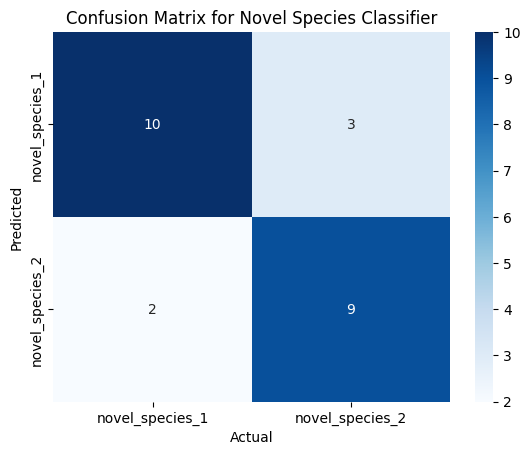

In [5]:
# Setting up data and labels
X = novel_species_df.drop(['Image', 'species'], axis=1)
y = novel_species_df['species']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Evaluation
accuracy = knn.score(X_test, y_test)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)

print("Overall Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Precision:", precision)
print("Recall:", recall)

# Plotting the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Confusion Matrix for Novel Species Classifier')
plt.show()

## Interpretation

Follow the guidelines in the `README` file

#### 1. Revisit your hypotheses from the introduction. How did your models do compared to your hypotheses? What was surprising and why?

__(a) California Gull vs Ring Billed Gull:__  After running our binary classifier model, we obtained an accuracy of 44.44% in distinguishing between the California Gull and the Ring-Billed Gull species, which was as expected given their very similar appearances each bird had to each other. 

__(b) Chipping Sparrow vs Fox Sparrow:__ After running our binary classifier model, we obtained an accuracy of 50% in distinguishing between the Chipping Sparrow and the Fox Sparrow species, which was as expcted given the similarity in size, shape, and especially color patterns between these two species which likely contributed to the difficulty in differentiation.

__(c) Pileated Woodpecker vs Red headed Woodpecker:__ After running our binary classifier model, we obtained an accuracy of 83.33% in distinguishing between the Pileated Woodpecker and the Red-headed Woodpecker species. this result was higher than we expected given both species had similar features and coloring as well as being in the same family.   
__(d) Blue Grosbeak vs Long tailed Jaeger:__  After running our binary classifier model, we obtained an accuracy of 77.77% in distinguishing between the Blue Grosbeak and the Long-tailed Jaeger species. This result was somewhat unexpected, given the easily distinguishable differences in color, size, and shape between these two bird species we expected the accuracy to be a bit higher than 77.77%.

__(e) White Pelican vs Yellow Warbler:__  After running our binary classifier model, we achieved a remarkable 100% accuracy in distinguishing between the White Pelican and Yellow Warbler species. While we expected a high accuracy score, achieving a perfect result was both impressive and surprising to us as a group.

__(f) Painted Bunting vs Summer Tanager:__ After running our binary classifier model, we achieved an accuracy of 82.86% in distinguishing between the Painted Bunting and the Summer Tanager species. Despite initially anticipating challenges due to their similar shape and size, the model performed remarkably well, as evidenced by the accuracy score.  

__(g) Hooded Warbler vs Red bellied Woodpecker:__  After running our binary classifier model, we achieved an accuracy of 94.44% in distinguishing between the Hooded Warbler and the Red-bellied Woodpecker species. This result was in line with our expectations, as the two species exhibit clear differences in color patterns that make differentiation easy between the two species.     

__(h) Red winged Blackbird vs Lazuli Bunting:__ After running our binary classifier model, we achieved an accuracy of 94.29% in distinguishing between the Red-winged Blackbird and Lazuli Bunting species. This result was expected, as the two species have distinct differences in color and shape, which made classification between them easy.   

__(i) Hooded Merganser vs Nighthawk:__ After running our binary classifier model, we achieved an accuracy of 94.44% in distinguishing between the Hooded Merganser and Nighthawk species. This result surprised us, as we originally thought the classifier might struggle due to both species exhibiting similar color patterns of brown and black. The model performed remarkably well, exceeding our expectations. 

__(j) Brown Pelican vs White Pelican:__  After running our binary classifier model, we achieved an accuracy of 87.87% in distinguishing between the Brown Pelican and White Pelican species. This result was the most surprising of all our comparisons, as we expected the binary classifier model to struggle with differentiating these two species. The Brown and White Pelicans look nearly identical, with the only clear difference being color. The model exceeded our expectations, performing remarkably better then we thought.  

#### 2. Discuss the precision and recall scores of each class for your various models. What seems to be your strongest model and why?

__(a) California Gull vs Ring Billed Gull:__ 
- The precision score for the positive class is `0.625`, indicating that `62.5%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.7`, indicating that `70%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5, the model can be considered as acceptable.
- The recall score for the positive class is `0.625`, indicating that `62.5%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.7`, indicating that `70%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5, so the model is generally acceptable.

__(b) Chipping Sparrow vs Fox Sparrow:__ 
- The precision score for the positive class is `0.5`, indicating that `50%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.6`, indicating that `60%` of the instances predicted as negative are actually negative. 
- The recall score for the positive class is `0.5`, indicating that `50%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.6`, indicating that `60%` of the actual negatives were correctly identified by the model.

__(c) Pileated Woodpecker vs Red headed Woodpecker:__ 
- The precision score for the positive class is `0.625`, indicating that `62.5%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.7`, indicating that `70%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5, the model can be considered as acceptable.
- The recall score for the positive class is `0.625`, indicating that `62.5%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.7`, indicating that `70%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5, so the model is generally acceptable.

__(d) Blue Grosbeak vs Long tailed Jaeger:__  
- The precision score for the positive class is `0.75`, indicating that `75%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.8`, indicating that `80%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5 and quite close to 1, it's safe to say the model is quite strong.
- The recall score for the positive class is `0.75`, indicating that `75%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.8`, indicating that `80%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5 and quite close to 1, so it's also safe to say the model is quite strong.

__(e) White Pelican vs Yellow Warbler:__ 
- The precision score for the positive class is `0.85714286`, indicating that approximately `85.7%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.89473684`, indicating that approximately `89.5%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5 and quite close to 1, it's safe to say the model is quite strong.
- The recall score for the positive class is `0.85714286`, indicating that approximately `85.7%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.89473684`, indicating that approximately `89.5%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5 and quite close to 1, so it's also safe to say the model is quite strong.

__(f) Painted Bunting vs Summer Tanager:__ 
- The precision score for the positive class is `0.86666667`, indicating that approximately `86.7%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.9`, indicating that approximately `90%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5 and quite close to 1, it's safe to say the model is quite strong.
- The recall score for the positive class is `0.86666667`, indicating that approximately `86.7%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.9`, indicating that `90%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5 and quite close to 1, so it's also safe to say the model is quite strong.

__(g) Hooded Warbler vs Red bellied Woodpecker:__  
- The precision score for the positive class is `0.6875`, indicating that `68.75%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.75`, indicating that `75%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5, the model can be considered as acceptable.
- The recall score for the positive class is `0.6875`, indicating that `68.75%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.75`, indicating that `75%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5, so the model is generally acceptable.

__(h) Red winged Blackbird vs Lazuli Bunting:__ 
- The precision score for the positive class is `0.86666667`, indicating that approximately `86.7%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.9`, indicating that approximately `90%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5 and quite close to 1, it's safe to say the model is quite strong.
- The recall score for the positive class is `0.86666667`, indicating that approximately `86.7%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.9`, indicating that `90%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5 and quite close to 1, so it's also safe to say the model is quite strong.

__(i) Hooded Merganser vs Nighthawk:__ 
- The precision score for the positive class is `0.75`, indicating that `75%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.8`, indicating that `80%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5 and quite close to 1, it's safe to say the model is quite strong.
- The recall score for the positive class is `0.75`, indicating that `75%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.8`, indicating that `80%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5 and quite close to 1, so it's also safe to say the model is quite strong.

__(j) Brown Pelican vs White Pelican:__  
- The precision score for the positive class is `0.54545455`, indicating that approximately `54.55%` of the instances predicted as positive are actually positive, while precision score for the negative class is `0.77272727`, indicating that approximately `77.27%` of the instances predicted as negative are actually negative. Because both precision scores are above 0.5, the model can be considered as acceptable.
- The recall score for the positive class is `0.54545455`, indicating that approximately `54.55%` of the actual positives were correctly identified by the model, while the recall score for the negative class is `0.77272727`, indicating that approximately `77.27%` of the actual negatives were correctly identified by the model. Once again, both of the recall scores are above 0.5, so the model is generally acceptable.

From the results, we noticed that the following two pairings have the highest set of pairing and recall scores: 
- __(f) Painted Bunting vs Summer Tanager__ 
- __(h) Red winged Blackbird vs Lazuli Bunting__ 

These two pairings both have the precision score of `0.86666667` for the positive class and `0.9` for the negative class, and the recall score of `0.86666667` for the positive class and `0.9` for the negative class. Both of the scores of both models are really close to 1, indicating that both models are relatively strong. 

It is also worth noting that throughout these models, both classes of the precision scores are the same as the recall scores in each model. This signifies balanced and stable performance across classes, and that the models are equally adept at correctly identifying both positive and negative instances while minimizing false positives and false negatives.

## Conclusion

Follow the guidelines in the `README` file

- In our lab, we learned how to use the Convolutional Neural Network (CNN) model to classify images and interpret the results provided by the CNN model. For our analysis, we utilized the Caltech-UCSD Birds-200-2011 Dataset (CUB 200), which contains numerous images of various species of North American birds. The dataset's organization, with separate files for each species containing images, streamlined the process of accessing and retrieving images for each bird species. One limitation we encountered was the dataset's size; even the CUB 200 dataset, which was 1.2 GB, was considered quite large. Our objective was to compare 10 pairs of bird species by training and evaluating multiple binary classifiers. We categorized the bird pairs into groups of hard, medium, and easy based on the difficulty of distinguishing each pair from the other. To test and predict each pair of bird species, we utilized the CNN model to classify numerous pairs of species, providing insights into the complexities of classification. This process helped us highlight the distinguishing features that pose challenges and those that facilitate accurate classification when comparing multiple images. The strengths of using the CNN model include its ability to automatically learn and extract features from images. This process is achieved through convolutional layers, which apply filters to the input image to detect patterns such as edges, textures, and shapes. However, CNN models do have limitations, such as having a fixed-size receptive field, which limits their ability to capture long-range dependencies and global context in images. Additionally, CNNs can be computationally expensive, especially when dealing with large images or deep architectures. To showcase our results from the CNN model, we used another method known as a confusion matrix. The strengths of a confusion matrix offers a detailed breakdown of predictions across multiple classes. It provides comprehensive evaluation through metrics like accuracy, precision, and recall, enabling fine-grained analysis of the model's behavior for each class. However, confusion matrices do not address uncertainty in predictions and may be insensitive to class imbalances, potentially impacting the interpretation of model performance.       